In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/DL/Transformer from Scratch


/content/drive/MyDrive/DL/Transformer from Scratch


In [11]:
# Thêm vào cell đầu tiên của notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
!ls


config.py	  Inference.ipynb   __pycache__        tokenizer_vi.json
Data_Medi	  main.ipynb	    RNNFinetune        training_chart.png
dataset_cache_vi  medical_finetune  runs	       train.py
dataset.py	  model.py	    test.ipynb	       weights
Finetune	  preprocess.py     tokenizer_en.json


In [3]:
%cd Finetune
!ls


/content/drive/MyDrive/DL/Transformer from Scratch/Finetune
config_finetune.py  med_dataset.py  train_finetune.py
DataMed.ipynb	    __pycache__     training_chart.png
FinetuneMed.ipynb   runs	    weights_finetune_300k


In [ ]:
!python train_finetune.py


2025-12-15 08:14:04.216709: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-15 08:14:04.235586: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765786444.257431   33170 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765786444.264038   33170 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765786444.281050   33170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 14.2 MB/s eta 0:00:00


In [9]:
import torch
from tqdm import tqdm
from tokenizers import Tokenizer
from datasets import load_from_disk
import sacrebleu
from pathlib import Path
import sys
import os
import torch.nn.functional as F
import random

# -------------------------------------------------
# FIX IMPORT PATH
# -------------------------------------------------
sys.path.append(str(Path(os.getcwd()).parent))

from model import build_transformer
from med_dataset import MedTranslationDataset

# -------------------------------------------------
# DEVICE & TOKENIZERS
# -------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer_src = Tokenizer.from_file("../tokenizer_en.json")
tokenizer_tgt = Tokenizer.from_file("../tokenizer_vi.json")

PAD_ID = tokenizer_tgt.token_to_id("[PAD]")
EOS_ID = tokenizer_tgt.token_to_id("[EOS]")
SOS_ID = tokenizer_tgt.token_to_id("[SOS]")

# -------------------------------------------------
# LOAD TEST DATA
# -------------------------------------------------
test_hf = load_from_disk("../Data_Medi/med_test")
test_dataset = MedTranslationDataset(
    test_hf, tokenizer_src, tokenizer_tgt, seq_len=350
)
print(f"Test size: {len(test_dataset)}")

# -------------------------------------------------
# LOAD FINETUNE MODEL
# -------------------------------------------------
print("Loading finetuned model from weights_finetune_300k/finetune_best.pt")
ckpt = torch.load("weights_finetune_300k/finetune_best.pt", map_location=device)

model = build_transformer(
    tokenizer_src.get_vocab_size(),
    tokenizer_tgt.get_vocab_size(),
    350,
    512,
).to(device)

state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
clean_state = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
model.load_state_dict(clean_state)
model.eval()
print("Loaded finetuned model")

# -------------------------------------------------
# BEAM SEARCH (dùng beam_size=1 -> greedy)
# -------------------------------------------------
def beam_search_translate(
    model, sentence, tokenizer_src, tokenizer_tgt,
    beam_size=1, max_len=60, length_penalty=0.8, repetition_penalty=1.4
):
    model.eval()
    device = next(model.parameters()).device
    sos, eos = SOS_ID, EOS_ID

    src_ids = tokenizer_src.encode(sentence).ids
    src = torch.tensor(src_ids).unsqueeze(0).to(device)
    src_mask = torch.ones(1, 1, src.size(1), dtype=torch.bool, device=device)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)

    beams = [([sos], 0.0)]
    for _ in range(max_len):
        candidates = []
        for tokens, score in beams:
            if tokens[-1] == eos:
                candidates.append((tokens, score))
                continue

            tgt = torch.tensor(tokens, device=device).unsqueeze(0)
            tgt_mask = torch.tril(
                torch.ones(1, tgt.size(1), tgt.size(1), device=device)
            ).bool()

            with torch.no_grad():
                dec_out = model.decode(enc_out, src_mask, tgt, tgt_mask)
                logits = model.project(dec_out[:, -1]).squeeze(0)
                log_probs = F.log_softmax(logits, dim=-1)

            for t in set(tokens):
                log_probs[t] /= repetition_penalty

            topk = torch.topk(log_probs, beam_size)  # beam_size=1 -> greedy
            for i in range(beam_size):
                next_tok = topk.indices[i].item()
                next_score = score + topk.values[i].item()
                candidates.append((tokens + [next_tok], next_score))

        beams = sorted(
            candidates,
            key=lambda x: x[1] / (len(x[0]) ** length_penalty),
            reverse=True,
        )[:beam_size]

        if all(b[0][-1] == eos for b in beams):
            break

    best = beams[0][0]
    if eos in best:
        best = best[1:best.index(eos)]
    else:
        best = best[1:]

    return tokenizer_tgt.decode(best)

# -------------------------------------------------
# EVALUATE BLEU TRÊN 2000 CÂU NGẪU NHIÊN
# -------------------------------------------------
N = 2000
total_size = len(test_dataset)
indices = random.sample(range(total_size), min(N, total_size))

print(f"Evaluating on {len(indices)} random test sentences...")
predictions = []
references = []

for i in tqdm(indices, desc="Evaluating BLEU"):
    src_text = test_dataset[i]["src_text"]
    tgt_text = test_dataset[i]["tgt_text"]

    pred = beam_search_translate(
        model, src_text, tokenizer_src, tokenizer_tgt,
        beam_size=1,   # greedy
        max_len=60
    )
    predictions.append(pred)
    references.append([tgt_text])

bleu = sacrebleu.corpus_bleu(predictions, references)
print(f"\n>> APPROX TEST BLEU (2000 samples, greedy): {bleu.score:.4f}")
print(f">> BLEU details: {bleu}")


Using device: cuda
Test size: 16581
Loading finetuned model from weights_finetune_300k/finetune_best.pt
Loaded finetuned model
Evaluating on 2000 random test sentences...


Evaluating BLEU: 100%|██████████| 2000/2000 [10:47<00:00,  3.09it/s]



>> APPROX TEST BLEU (2000 samples, greedy): 38.9578
>> BLEU details: BLEU = 38.96 95.3/76.2/31.7/10.0 (BP = 1.000 ratio = 1.000 hyp_len = 43 ref_len = 43)


In [12]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn_test(batch):
    encoder_input_list = [b["encoder_input"] for b in batch]
    decoder_input_list = [b["decoder_input"] for b in batch]
    label_list = [b["label"] for b in batch]

    encoder_input = pad_sequence(
        encoder_input_list, batch_first=True, padding_value=PAD_ID
    )
    decoder_input = pad_sequence(
        decoder_input_list, batch_first=True, padding_value=PAD_ID
    )
    label = pad_sequence(
        label_list, batch_first=True, padding_value=PAD_ID
    )

    encoder_mask = (encoder_input != PAD_ID).unsqueeze(1).unsqueeze(2).int()
    size = decoder_input.size(1)
    causal = torch.tril(
        torch.ones(1, size, size, dtype=torch.int, device=encoder_input.device)
    )
    decoder_mask = (
        (decoder_input != PAD_ID).unsqueeze(1).unsqueeze(2).int() & causal
    )

    return {
        "encoder_input": encoder_input,
        "decoder_input": decoder_input,
        "label": label,
        "encoder_mask": encoder_mask,
        "decoder_mask": decoder_mask,
    }

print("\nCalculating perplexity on test set...")
model.eval()
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn_test,  # dùng collate_fn thay vì default
)

total_loss = 0.0
total_tokens = 0

vocab_size = tokenizer_tgt.get_vocab_size()
weights = torch.ones(vocab_size, device=device)
weights[PAD_ID] = 0.0
criterion = torch.nn.CrossEntropyLoss(weight=weights, ignore_index=PAD_ID)

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Perplexity"):
        src = batch["encoder_input"].to(device)
        tgt_in = batch["decoder_input"].to(device)
        tgt_out = batch["label"].to(device)
        src_mask = batch["encoder_mask"].to(device)
        tgt_mask = batch["decoder_mask"].to(device)

        enc_out = model.encode(src, src_mask)
        dec_out = model.decode(enc_out, src_mask, tgt_in, tgt_mask)
        logits = model.project(dec_out)

        loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.view(-1))
        total_loss += loss.item() * (tgt_out != PAD_ID).sum().item()
        total_tokens += (tgt_out != PAD_ID).sum().item()

avg_loss = total_loss / total_tokens
perplexity = torch.exp(torch.tensor(avg_loss))
print(f">> TEST PERPLEXITY: {perplexity:.2f}")
print(f">> Average NLL loss: {avg_loss:.4f}")



Calculating perplexity on test set...


Perplexity: 100%|██████████| 519/519 [00:22<00:00, 23.20it/s]

>> TEST PERPLEXITY: 4.68
>> Average NLL loss: 1.5437


Đang đọc dữ liệu từ: runs/tmodel_finetune/events.out.tfevents.1765786450.4e06ae1a0b6c.33170.0
Các metrics tìm thấy: ['train loss', 'val loss']


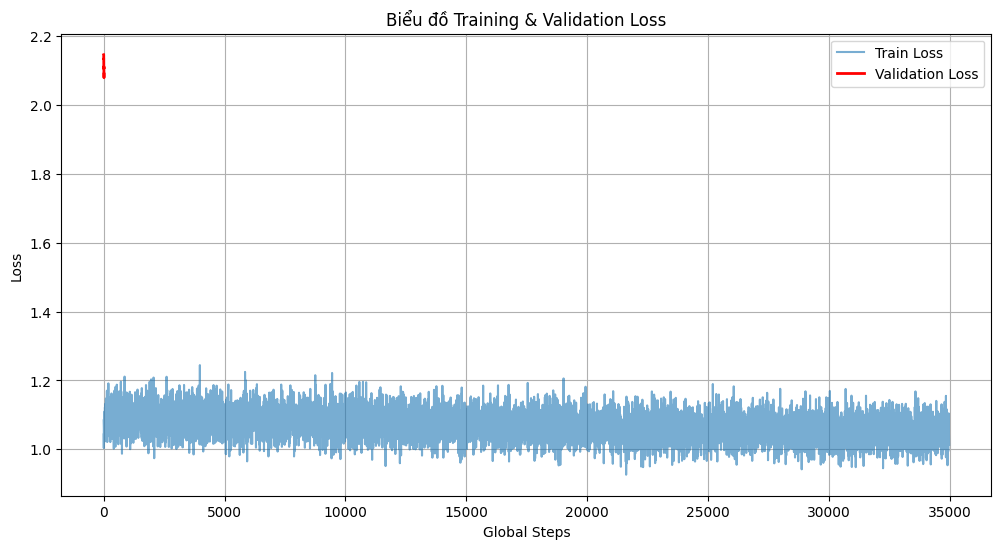

Đã lưu biểu đồ thành công vào training_chart.png


In [13]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os
import glob

def plot_training_results(log_dir="runs/tmodel_finetune"):
    # Tìm file log mới nhất trong thư mục
    list_of_files = glob.glob(f'{log_dir}/*')
    if not list_of_files:
        print("Không tìm thấy file log nào trong thư mục:", log_dir)
        return

    # Lấy file mới nhất
    latest_file = max(list_of_files, key=os.path.getctime)
    print(f"Đang đọc dữ liệu từ: {latest_file}")

    # Load dữ liệu
    event_acc = EventAccumulator(latest_file)
    event_acc.Reload()

    # Lấy danh sách các thẻ (tags) có sẵn
    tags = event_acc.Tags()['scalars']
    print("Các metrics tìm thấy:", tags)

    # Chuẩn bị dữ liệu vẽ
    plt.figure(figsize=(12, 6))

    # 1. Vẽ Train Loss
    if 'train loss' in tags:
        train_loss = event_acc.Scalars('train loss')
        steps = [x.step for x in train_loss]
        values = [x.value for x in train_loss]
        plt.plot(steps, values, label='Train Loss', alpha=0.6)

    # 2. Vẽ Validation Loss
    if 'val loss' in tags:
        val_loss = event_acc.Scalars('val loss')
        v_steps = [x.step for x in val_loss]
        v_values = [x.value for x in val_loss]
        plt.plot(v_steps, v_values, label='Validation Loss', linewidth=2, color='red')

    plt.title("Biểu đồ Training & Validation Loss")
    plt.xlabel("Global Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Lưu ảnh
    plt.savefig("training_chart.png")
    plt.show()
    print("Đã lưu biểu đồ thành công vào training_chart.png")

# Chạy hàm vẽ
plot_training_results()

In [17]:
model_code = r"""
import math
import torch
import torch.nn as nn

class InputEmbeddings(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(0, seq_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].requires_grad_(False)
        return self.dropout(x)

class LayerNormalization(nn.Module):

    def __init__(self, features: int, eps: float = 10**-6) -> None:
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(features))
        self.bias = nn.Parameter(torch.zeros(features))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        return self.alpha * (x - mean) / (std + self.eps) + self.bias

class FeedForwardBlock(nn.Module):

    def __init__(self, d_model:int, d_ff :int, dropout: float):
        super().__init__()
        self.liner1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.liner2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.liner2(self.dropout(torch.relu(self.liner1(x))))

class MultiheadAttentionBlock(nn.Module):

    def __init__(self, d_model: int, h: int, droupout: float):
        super().__init__()
        self.d_model = d_model
        self.h = h
        assert d_model % h == 0, "d_model must be divisible by h"

        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(droupout)

    @staticmethod
    def attention(query, key, value, mask, droupout : nn.Dropout):
        d_k = query.shape[-1]
        attention_scores = (query @ key.transpose(-2,-1)) / math.sqrt(d_k)
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == True, -1e9)

        attention_scores = attention_scores.softmax(dim=-1)

        if droupout is not None:
            attention_scores = droupout(attention_scores)

        return (attention_scores @ value), attention_scores

    def forward(self, q, k, v, mask):
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)

        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1 ,2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1 ,2)
        value = value.view(value.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)

        x, self.attention_scores = MultiheadAttentionBlock.attention(query, key, value, mask, self.dropout)

        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)

        return self.w_o(x)

class ResidualConnection(nn.Module):

    def __init__(self, fetures: int, dropout: float):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization(fetures)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

class EncoderBlock(nn.Module):

    def __init__(self, fetures: int, self_attention_block: MultiheadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(fetures,dropout) for _ in range(2)])

    def forward(self, x, src_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_connections[1](x, self.feed_forward_block)
        return x

class Encoder(nn.Module):

    def __init__(self, layers: nn.ModuleList, d_model: int):
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization(d_model)

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x,mask)
        return self.norm(x)

class DecoderBlock(nn.Module):

    def __init__(self, fetures: int, self_attention_block: MultiheadAttentionBlock, cross_attention_block: MultiheadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float):
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(fetures,dropout) for _ in range(3)])

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x,x,x,tgt_mask))
        x = self.residual_connections[1](x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connections[2](x, self.feed_forward_block)
        return x

class Decoder(nn.Module):

    def __init__(self, Layers: nn.ModuleList, d_model: int):
        super().__init__()
        self.layers = Layers
        self.norm = LayerNormalization(d_model)

    def forward(self, x, encoder_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)

class ProjectionLayer(nn.Module):

    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.projection = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return self.projection(x)

class Transformer(nn.Module):

    def __init__(self, encoder: Encoder, decoder: Decoder, src_embed: InputEmbeddings, tgt_embed: InputEmbeddings, src_pos: PositionalEncoding, tgt_pos: PositionalEncoding, projection_layer: ProjectionLayer):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer

    def encode(self, src, src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)

    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)

    def project(self, x):
        return self.projection_layer(x)

def build_transformer(src_vocab_size: int, tgt_vocab_size : int, src_seq_len : int, d_model: int = 512, N :int = 6, h : int = 8, dropout: float = 0.1, d_ff : int =2048) -> Transformer:
    src_embed = InputEmbeddings(d_model, src_vocab_size)
    tgt_embed = InputEmbeddings(d_model, tgt_vocab_size)

    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    tgt_pos = PositionalEncoding(d_model, src_seq_len, dropout)

    encoder_blocks = []
    for _ in range(N):
        self_attention_block = MultiheadAttentionBlock(d_model,h,dropout)
        feed_forward_block = FeedForwardBlock(d_model,d_ff,dropout)
        encoder_block = EncoderBlock(d_model,self_attention_block, feed_forward_block, dropout)
        encoder_blocks.append(encoder_block)

    decoder_blocks = []
    for _ in range(N):
        self_attention_block = MultiheadAttentionBlock(d_model,h,dropout)
        cross_attention_block = MultiheadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model,d_ff,dropout)
        decoder_blocks.append(DecoderBlock(d_model,self_attention_block, cross_attention_block, feed_forward_block, dropout))

    encoder = Encoder(nn.ModuleList(encoder_blocks), d_model)
    decoder = Decoder(nn.ModuleList(decoder_blocks), d_model)

    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)

    transfomer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer)

    for p in transfomer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    return transfomer
"""

with open("/content/drive/MyDrive/DL/Transformer from Scratch/model_fixed.py", "w") as f:
    f.write(model_code)

print("Saved fixed file.")


Saved fixed file.


In [21]:
import torch
from tqdm import tqdm
from tokenizers import Tokenizer
from datasets import load_from_disk
import sacrebleu
from pathlib import Path
import sys
import os
import torch.nn.functional as F
import random

# -------------------------------------------------
# FIX IMPORT PATH
# -------------------------------------------------
current_dir = Path(os.getcwd())          # .../Transformer from Scratch/Finetune
parent_dir = current_dir.parent          # .../Transformer from Scratch
sys.path.append(str(parent_dir))

from model import build_transformer       # model gốc baseline
from med_dataset import MedTranslationDataset

# -------------------------------------------------
# DEVICE & TOKENIZERS
# -------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer_src = Tokenizer.from_file("../tokenizer_en.json")
tokenizer_tgt = Tokenizer.from_file("../tokenizer_vi.json")

PAD_ID = tokenizer_tgt.token_to_id("[PAD]")
EOS_ID = tokenizer_tgt.token_to_id("[EOS]")
SOS_ID = tokenizer_tgt.token_to_id("[SOS]")

# -------------------------------------------------
# LOAD TEST DATA
# -------------------------------------------------
test_hf = load_from_disk("../Data_Medi/med_test")
test_dataset = MedTranslationDataset(
    test_hf, tokenizer_src, tokenizer_tgt, seq_len=350
)
print(f"Test size: {len(test_dataset)}")

# -------------------------------------------------
# LOAD BASELINE MODEL (3M dòng)
# -------------------------------------------------
print("Loading baseline checkpoint...")
ckpt = torch.load("../weights/tmodel_best.pt", map_location=device)

model = build_transformer(
    tokenizer_src.get_vocab_size(),
    tokenizer_tgt.get_vocab_size(),
    350,
    512,
).to(device)

state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
clean_state = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

missing, unexpected = model.load_state_dict(clean_state, strict=True)
print("Loaded baseline model")
print("Missing keys:", len(missing), "| Unexpected:", len(unexpected))

model.eval()

# -------------------------------------------------
# BEAM SEARCH (beam_size=1 -> greedy)
# -------------------------------------------------
def beam_search_translate(
    model, sentence, tokenizer_src, tokenizer_tgt,
    beam_size=1, max_len=60, length_penalty=0.8, repetition_penalty=1.4
):
    model.eval()
    device = next(model.parameters()).device
    sos, eos = SOS_ID, EOS_ID

    src_ids = tokenizer_src.encode(sentence).ids
    src = torch.tensor(src_ids).unsqueeze(0).to(device)
    src_mask = torch.ones(1, 1, src.size(1), dtype=torch.bool, device=device)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)

    beams = [([sos], 0.0)]
    for _ in range(max_len):
        candidates = []
        for tokens, score in beams:
            if tokens[-1] == eos:
                candidates.append((tokens, score))
                continue

            tgt = torch.tensor(tokens, device=device).unsqueeze(0)
            tgt_mask = torch.tril(
                torch.ones(1, tgt.size(1), tgt.size(1), device=device)
            ).bool()

            with torch.no_grad():
                dec_out = model.decode(enc_out, src_mask, tgt, tgt_mask)
                logits = model.project(dec_out[:, -1]).squeeze(0)
                log_probs = F.log_softmax(logits, dim=-1)

            for t in set(tokens):
                log_probs[t] /= repetition_penalty

            topk = torch.topk(log_probs, beam_size)  # beam_size=1 -> greedy
            for i in range(beam_size):
                next_tok = topk.indices[i].item()
                next_score = score + topk.values[i].item()
                candidates.append((tokens + [next_tok], next_score))

        beams = sorted(
            candidates,
            key=lambda x: x[1] / (len(x[0]) ** length_penalty),
            reverse=True,
        )[:beam_size]

        if all(b[0][-1] == eos for b in beams):
            break

    best = beams[0][0]
    if eos in best:
        best = best[1:best.index(eos)]
    else:
        best = best[1:]

    return tokenizer_tgt.decode(best)

# -------------------------------------------------
# EVALUATE BLEU TRÊN 2000 CÂU NGẪU NHIÊN
# -------------------------------------------------
N = 2000
total_size = len(test_dataset)
indices = random.sample(range(total_size), min(N, total_size))

print(f"Evaluating on {len(indices)} random test sentences...")
predictions = []
references = []

for i in tqdm(indices, desc="Evaluating BLEU (baseline)"):
    src_text = test_dataset[i]["src_text"]
    tgt_text = test_dataset[i]["tgt_text"]

    pred = beam_search_translate(
        model, src_text, tokenizer_src, tokenizer_tgt,
        beam_size=1,   # greedy
        max_len=60
    )
    predictions.append(pred)
    references.append([tgt_text])

bleu = sacrebleu.corpus_bleu(predictions, references)
print(f"\n>> BASELINE TEST BLEU (2000 samples, greedy): {bleu.score:.4f}")
print(f">> BLEU details: {bleu}")


Using device: cuda
Test size: 16581
Loading baseline checkpoint...
Loaded baseline model
Missing keys: 0 | Unexpected: 0
Evaluating on 2000 random test sentences...


Evaluating BLEU (baseline): 100%|██████████| 2000/2000 [00:36<00:00, 55.37it/s]



>> BASELINE TEST BLEU (2000 samples, greedy): 0.0000
>> BLEU details: BLEU = 0.00 0.0/0.0/0.0/0.0 (BP = 0.000 ratio = 0.000 hyp_len = 0 ref_len = 3)


In [22]:
for i in range(5):
    src_text = test_dataset[i]["src_text"]
    tgt_text = test_dataset[i]["tgt_text"]
    pred = beam_search_translate(
        model, src_text, tokenizer_src, tokenizer_tgt,
        beam_size=1, max_len=60
    )
    print("SRC:", src_text)
    print("TGT:", tgt_text)
    print("PRD:", repr(pred))
    print("-" * 50)


SRC: 43.1% of patients were treated with IVIG.
TGT: 22 (43,1%) trẻ có điều trị IVIG.
PRD: ''
--------------------------------------------------
SRC: The true question seems to be whether there is a unique type of diabetes related to direct viral toxicity.
TGT: Câu hỏi thực sự là liệu có một loại đái tháo đường duy nhất liên quan đến độc tính trực tiếp của virus hay không.
PRD: ''
--------------------------------------------------
SRC: Objectives: The study aimed to evaluate the criteria for quality of glomerular filtration of white blood cells with platelet nourishment solution prepared from top-bottom three (350ml) bag system at Hematology Blood Transfusion Hospital.
TGT: Mục tiêu: Đánh giá các chỉ tiêu chất lượng khối tiểu cầu pool lọc bạch cầu có dung dịch nuôi dưỡng tiểu cầu được điều chế từ hệ thống túi ba (350 ml) đỉnh – đáy trên thiết bị tách tế bào máu tự động tại Bệnh viện Truyền máu Huyết học.
PRD: ''
--------------------------------------------------
SRC: Conclusion: Contusi

In [15]:
model_code = r"""
<dán toàn bộ code model_fixed.py ở đây>
"""

with open("/content/drive/MyDrive/DL/Transformer from Scratch/model_fixed.py", "w") as f:
    f.write(model_code)

print("Saved:", "/content/drive/MyDrive/DL/Transformer from Scratch/model_fixed.py")


Saved: /content/drive/MyDrive/DL/Transformer from Scratch/model_fixed.py
